# 📊 Notebook 1 — Data Inspection, Visualisation & Cleaning
**Project:** Real-Time Customer Churn Analysis Agent  
**Dataset:** Telco Customer Churn (Kaggle)  
**Goal:** Understand the raw data, surface quality issues, visualise key patterns, and produce a clean DataFrame ready for feature engineering.

---
### Table of Contents
1. [Setup & Imports](#1)
2. [Load Data](#2)
3. [Data Inspection](#3)
4. [Univariate Visualisations](#4)
5. [Bivariate Visualisations](#5)
6. [Correlation Heatmap](#6)
7. [Data Cleaning](#7)
8. [Save Cleaned Data](#8)

---
## 1. Setup & Imports <a id='1'></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── consistent plot style ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
CHURN_PALETTE = {'Yes': '#e74c3c', 'No': '#2ecc71'}   # red = churned, green = retained

print('Libraries loaded ✔')

Libraries loaded ✔


---
## 2. Load Data <a id='2'></a>

In [15]:
# ── adjust path if your dataset lives elsewhere ───────────────────────────────
DATA_PATH = '../data/telco_churn.csv'

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()           # keep the original untouched for reference

print(f'Dataset shape : {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
df.head()

Dataset shape : 7,043 rows  ×  21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## 3. Data Inspection <a id='3'></a>
### 3.1 Schema & dtypes

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 3.2 Basic statistics

In [17]:
# numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [18]:
# categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}):')
for col in cat_cols:
    print(f'  {col:30s}  unique={df[col].nunique():>4}   sample={df[col].unique()[:5]}')

Categorical columns (18):
  customerID                      unique=7043   sample=['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU']
  gender                          unique=   2   sample=['Female' 'Male']
  Partner                         unique=   2   sample=['Yes' 'No']
  Dependents                      unique=   2   sample=['No' 'Yes']
  PhoneService                    unique=   2   sample=['No' 'Yes']
  MultipleLines                   unique=   3   sample=['No phone service' 'No' 'Yes']
  InternetService                 unique=   3   sample=['DSL' 'Fiber optic' 'No']
  OnlineSecurity                  unique=   3   sample=['No' 'Yes' 'No internet service']
  OnlineBackup                    unique=   3   sample=['Yes' 'No' 'No internet service']
  DeviceProtection                unique=   3   sample=['No' 'Yes' 'No internet service']
  TechSupport                     unique=   3   sample=['No' 'Yes' 'No internet service']
  StreamingTV                     unique=   3 

### 3.3 Missing values

In [19]:
missing = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing %'     : (df.isnull().mean() * 100).round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

if missing.empty:
    print('✔ No explicit NaN values found.')
else:
    display(missing.style.background_gradient(cmap='Reds'))

✔ No explicit NaN values found.


In [20]:
# TotalCharges is stored as object in the raw CSV — check for hidden whitespace
print('TotalCharges dtype :', df['TotalCharges'].dtype)
print('Whitespace-only cells:', (df['TotalCharges'].str.strip() == '').sum())
print('Sample values        :', df['TotalCharges'].head(10).tolist())

TotalCharges dtype : object
Whitespace-only cells: 11
Sample values        : ['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95']


### 3.4 Duplicate rows

In [21]:
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')

Duplicate rows: 0


### 3.5 Target class distribution

In [22]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('Churn distribution:')
for label in churn_counts.index:
    print(f'  {label:4s}  →  {churn_counts[label]:,}  ({churn_pct[label]:.1f}%)')

Churn distribution:
  No    →  5,174  (73.5%)
  Yes   →  1,869  (26.5%)


---
## 4. Univariate Visualisations <a id='4'></a>
### 4.1 Target class balance

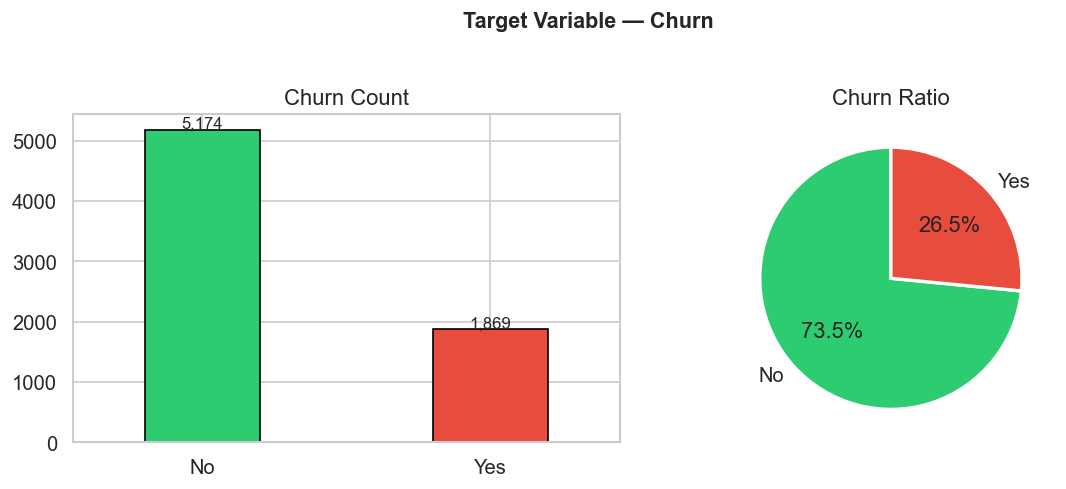

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# bar
churn_counts.plot(kind='bar', ax=axes[0], color=[CHURN_PALETTE[l] for l in churn_counts.index],
                  edgecolor='black', width=0.4)
axes[0].set_title('Churn Count')
axes[0].set_xlabel('')
axes[0].set_xticklabels(churn_counts.index, rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10)

# pie
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=[CHURN_PALETTE[l] for l in churn_counts.index],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Churn Ratio')

plt.suptitle('Target Variable — Churn', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Numeric feature distributions

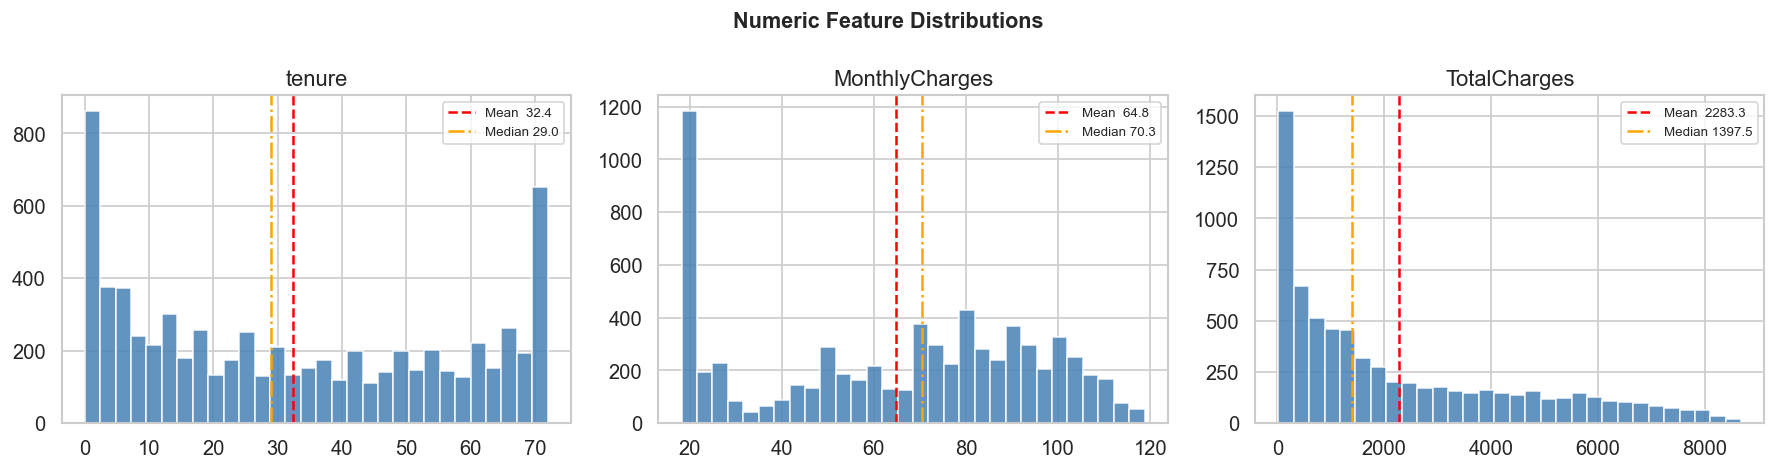

In [24]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']   # will be valid after cleaning

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# temporarily coerce TotalCharges for this plot
_tc = pd.to_numeric(df['TotalCharges'], errors='coerce')

for ax, col in zip(axes, num_cols):
    data = df[col] if col != 'TotalCharges' else _tc
    ax.hist(data.dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red',    linestyle='--', label=f'Mean  {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='-.',  label=f'Median {data.median():.1f}')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Numeric Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Categorical feature distributions

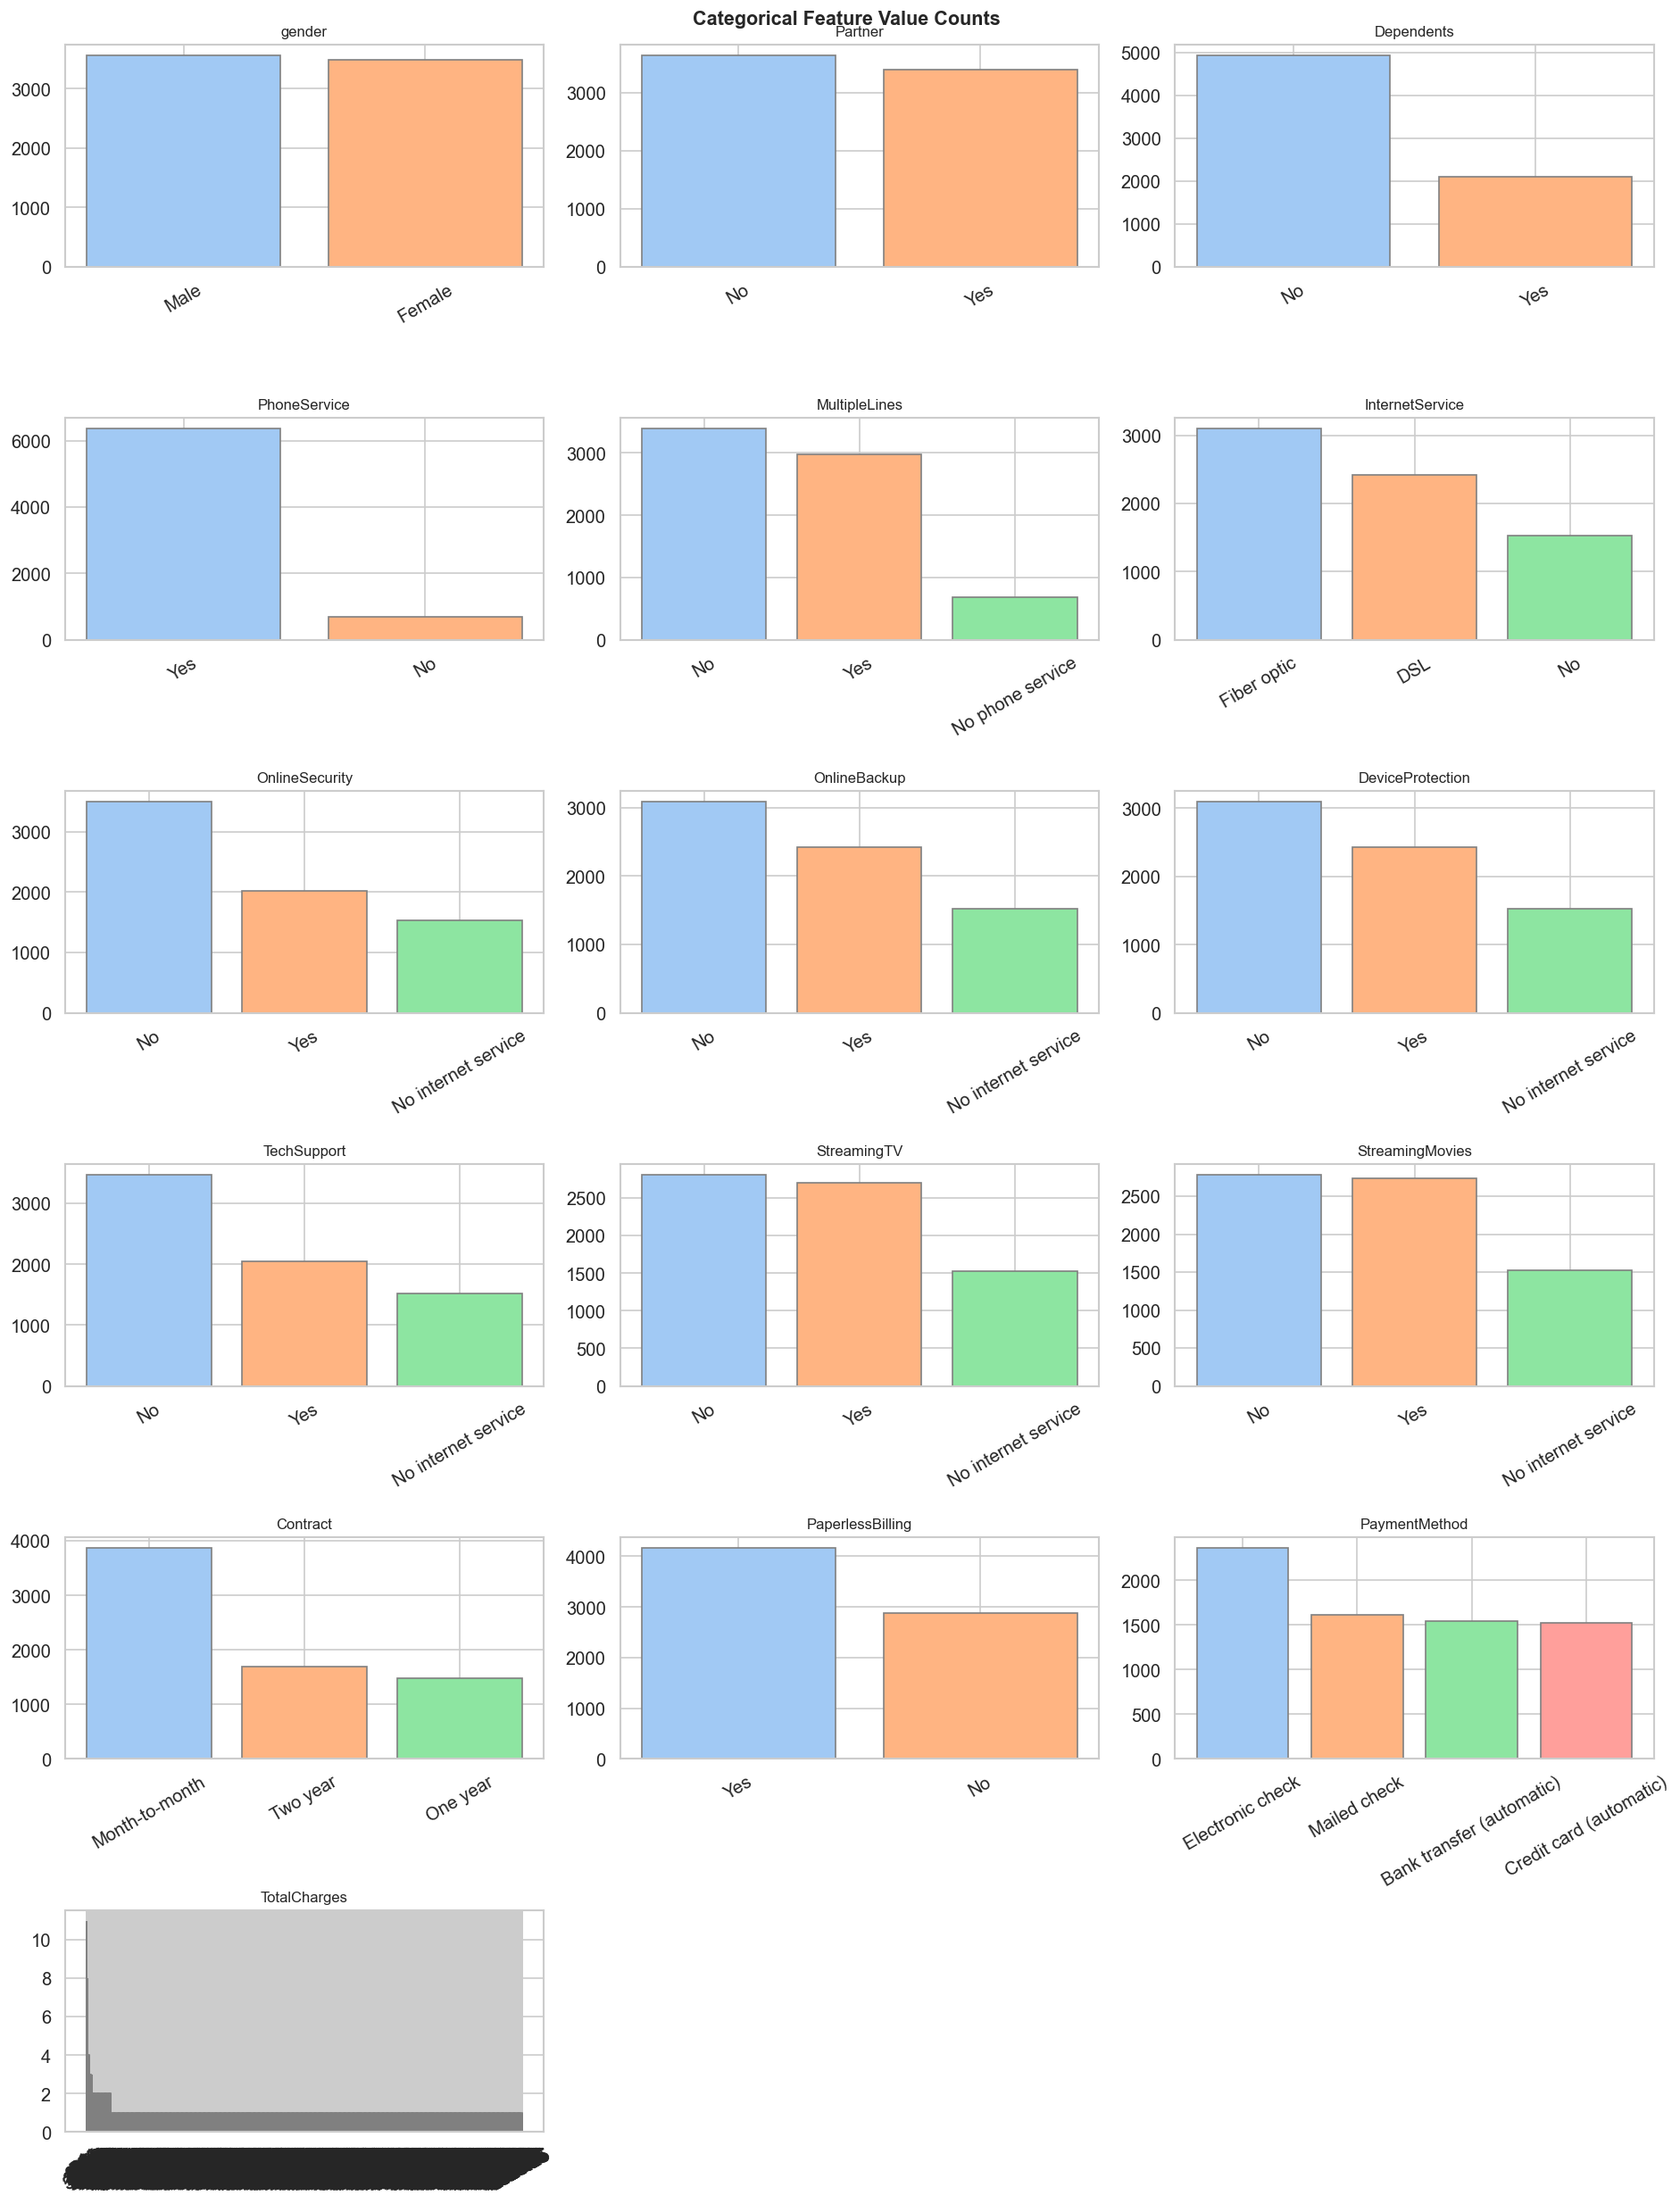

In [25]:
# pick the most informative categoricals (exclude customerID & Churn)
plot_cats = [c for c in cat_cols if c not in ('customerID', 'Churn')]

n_cols = 3
n_rows = (len(plot_cats) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(plot_cats):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=sns.color_palette('pastel'), edgecolor='grey')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=30)

# hide spare axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Value Counts', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Bivariate Visualisations (vs. Churn) <a id='5'></a>
### 5.1 Numeric features vs Churn — KDE + box plots

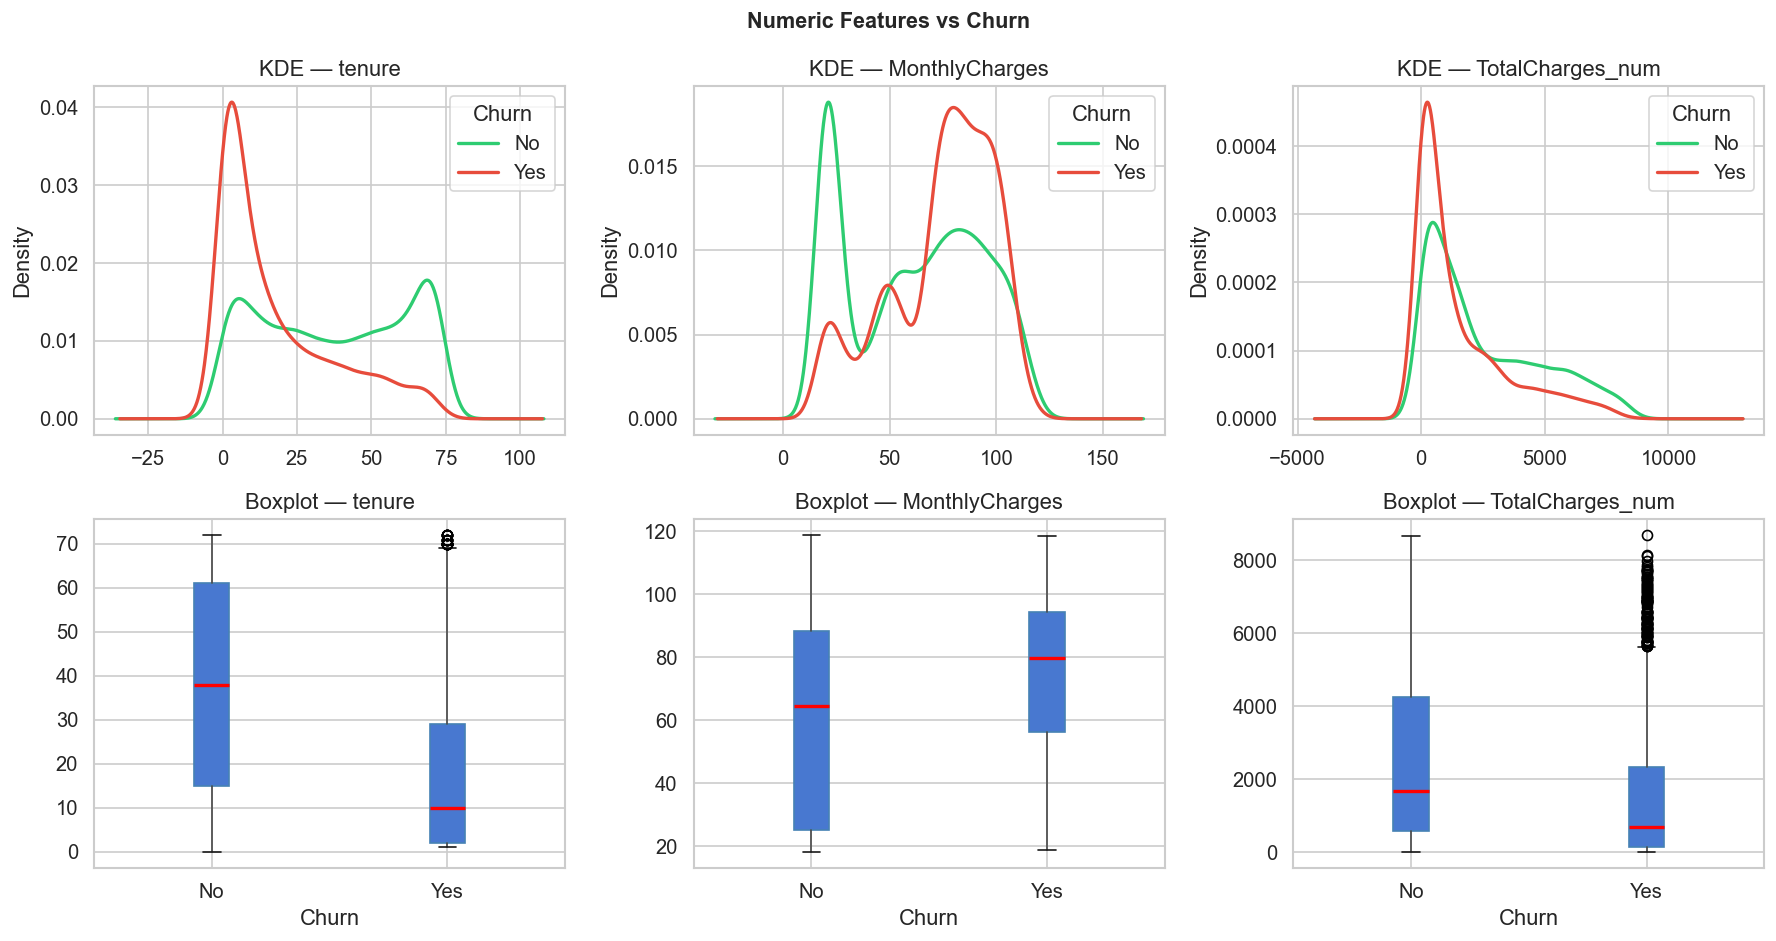

In [26]:
# temporarily coerce TotalCharges
df['TotalCharges_num'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
plot_nums = ['tenure', 'MonthlyCharges', 'TotalCharges_num']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(plot_nums):
    # KDE
    for label, grp in df.groupby('Churn'):
        grp[col].dropna().plot.kde(ax=axes[0, i], label=label,
                                   color=CHURN_PALETTE[label], linewidth=2)
    axes[0, i].set_title(f'KDE — {col}')
    axes[0, i].legend(title='Churn')

    # Box
    df.boxplot(column=col, by='Churn', ax=axes[1, i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2),
               patch_artist=True)
    axes[1, i].set_title(f'Boxplot — {col}')
    axes[1, i].set_xlabel('Churn')

plt.suptitle('Numeric Features vs Churn', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

df.drop(columns='TotalCharges_num', inplace=True)  # clean temp column

### 5.2 Categorical features vs Churn — stacked 100% bars

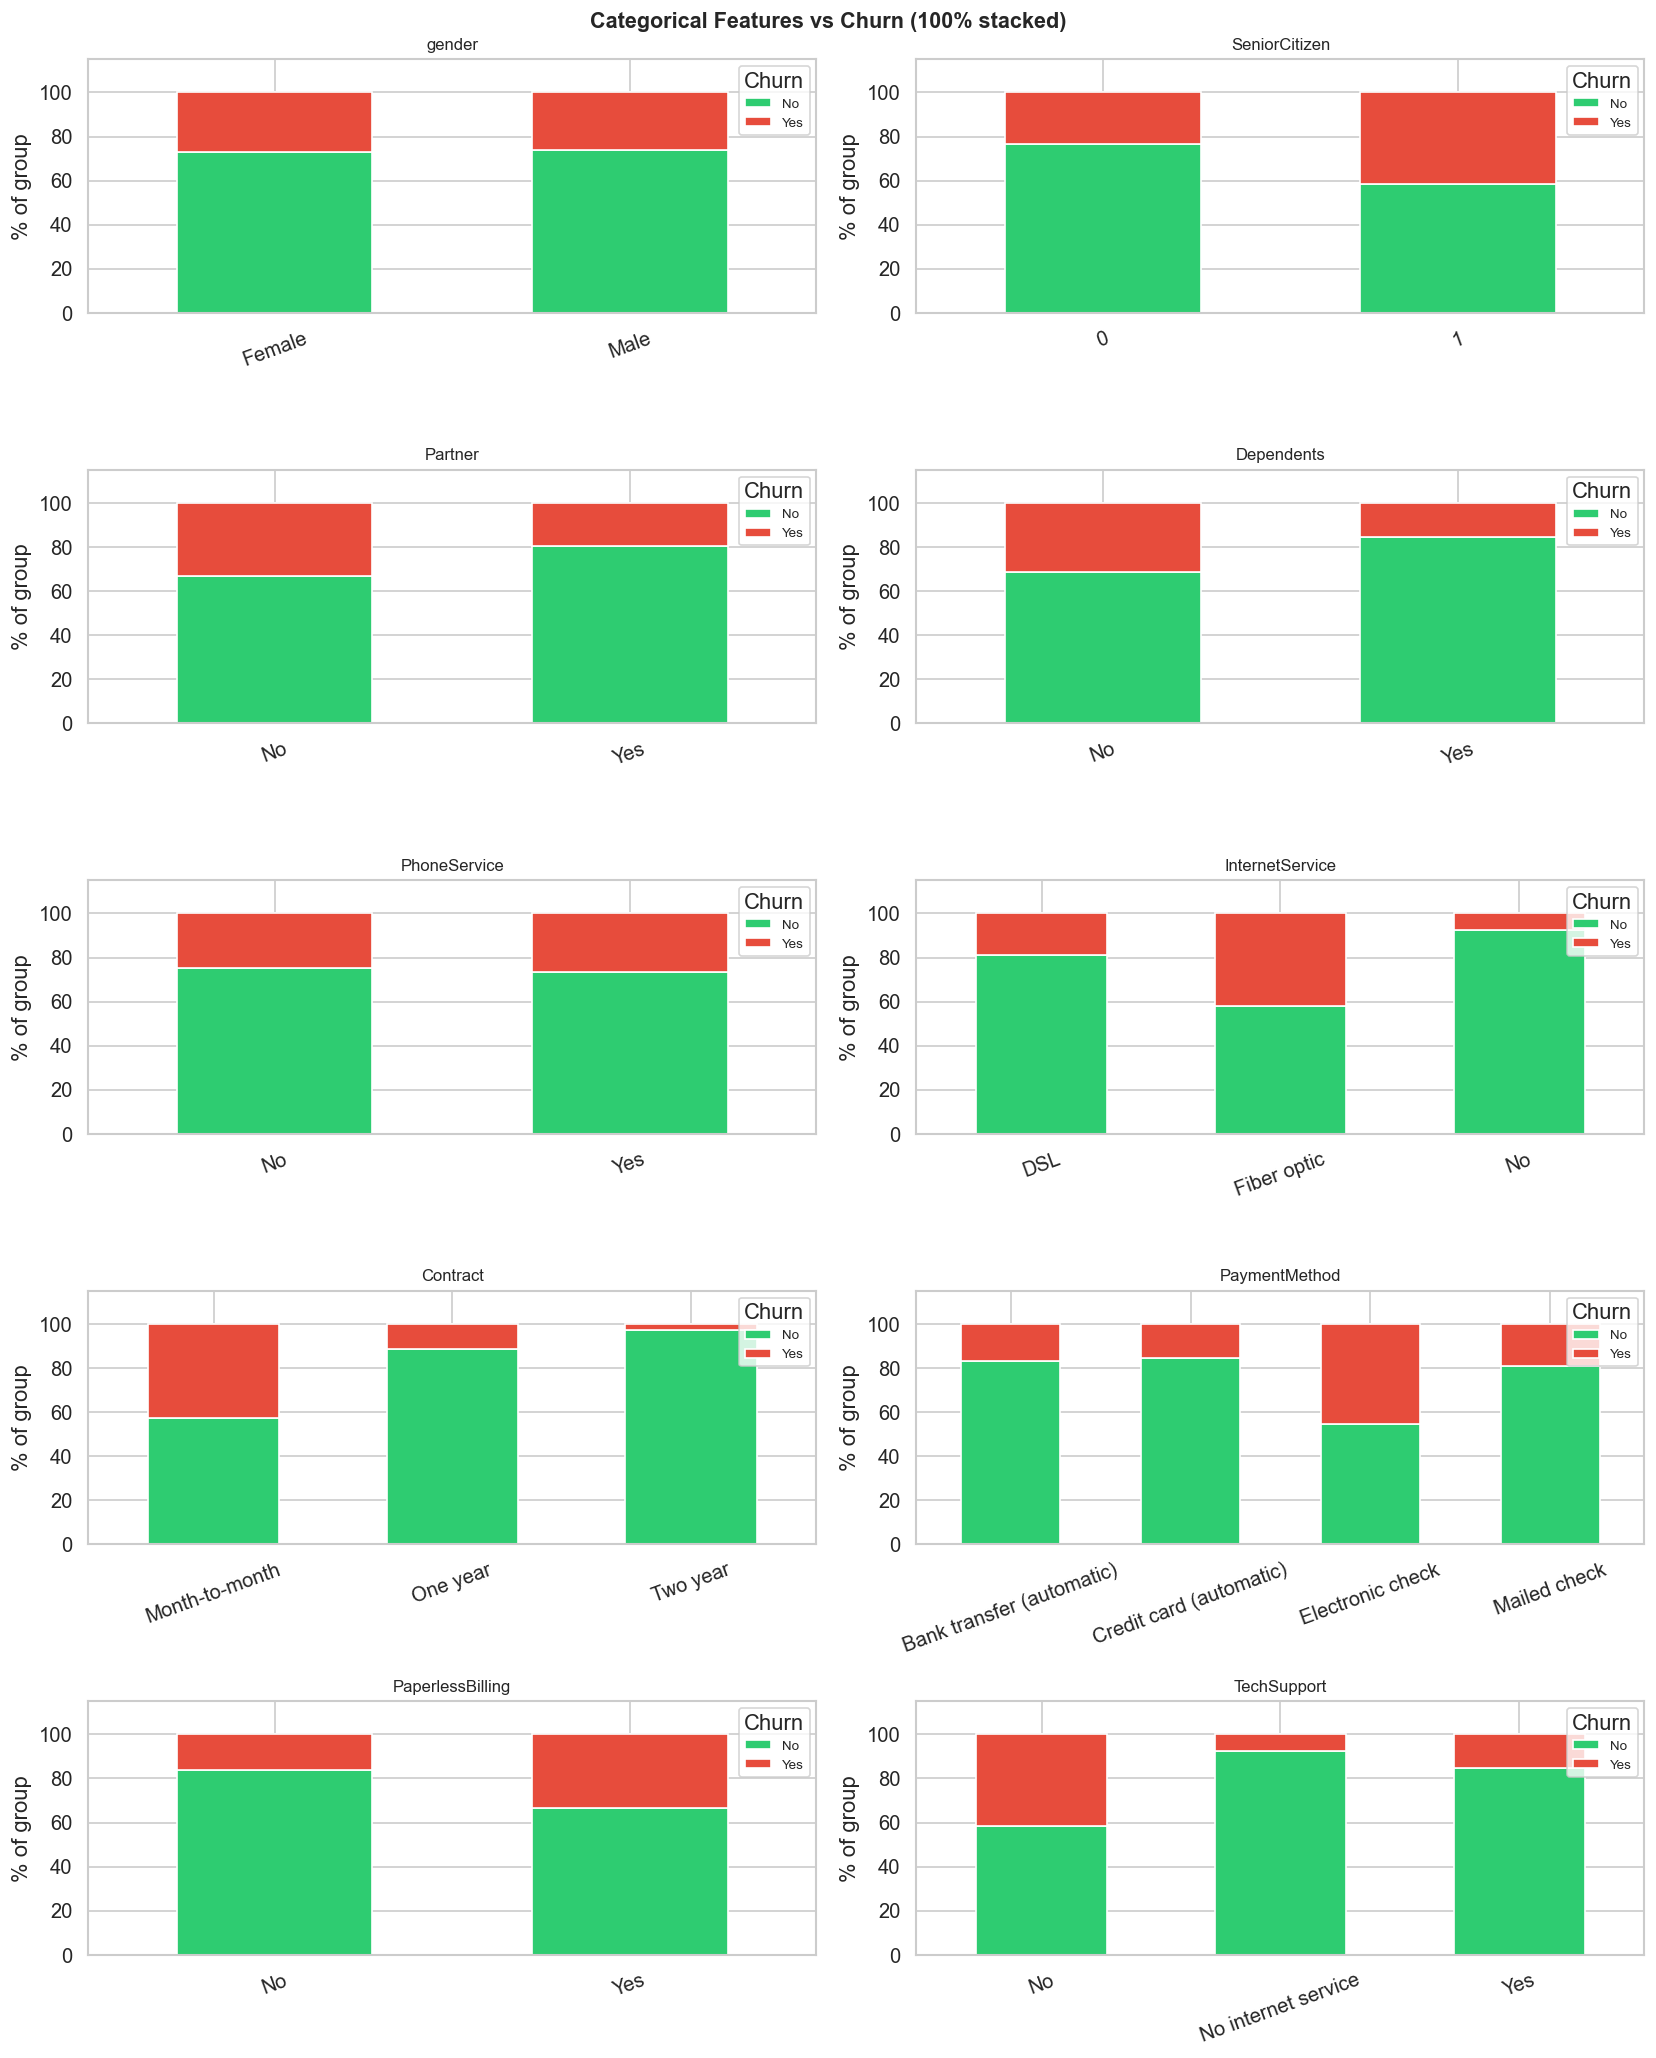

In [27]:
# key service / demographic columns
key_cats = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'InternetService', 'Contract',
            'PaymentMethod', 'PaperlessBilling', 'TechSupport']

n_cols = 2
n_rows = (len(key_cats) + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=[CHURN_PALETTE['No'], CHURN_PALETTE['Yes']],
            edgecolor='white', width=0.55)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('% of group')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].legend(title='Churn', loc='upper right', fontsize=8)
    axes[i].set_ylim(0, 115)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs Churn (100% stacked)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Tenure buckets vs Churn rate

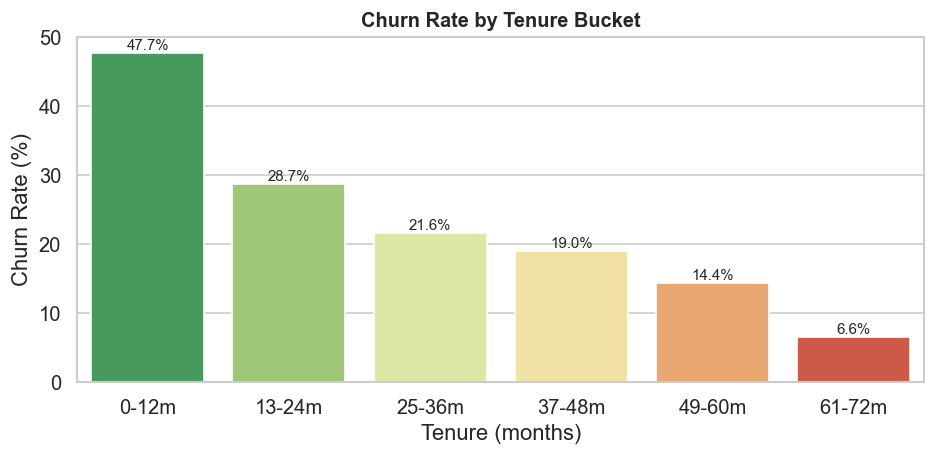

In [28]:
df['tenure_bin'] = pd.cut(df['tenure'], bins=[0, 12, 24, 36, 48, 60, 72],
                           labels=['0-12m', '13-24m', '25-36m', '37-48m', '49-60m', '61-72m'])

churn_by_tenure = (df.groupby('tenure_bin')['Churn']
                     .apply(lambda x: (x == 'Yes').mean() * 100)
                     .reset_index(name='ChurnRate%'))

plt.figure(figsize=(8, 4))
sns.barplot(data=churn_by_tenure, x='tenure_bin', y='ChurnRate%', palette='RdYlGn_r')
plt.title('Churn Rate by Tenure Bucket', fontsize=12, fontweight='bold')
plt.xlabel('Tenure (months)')
plt.ylabel('Churn Rate (%)')
for bar in plt.gca().patches:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

df.drop(columns='tenure_bin', inplace=True)

---
## 6. Correlation Heatmap <a id='6'></a>

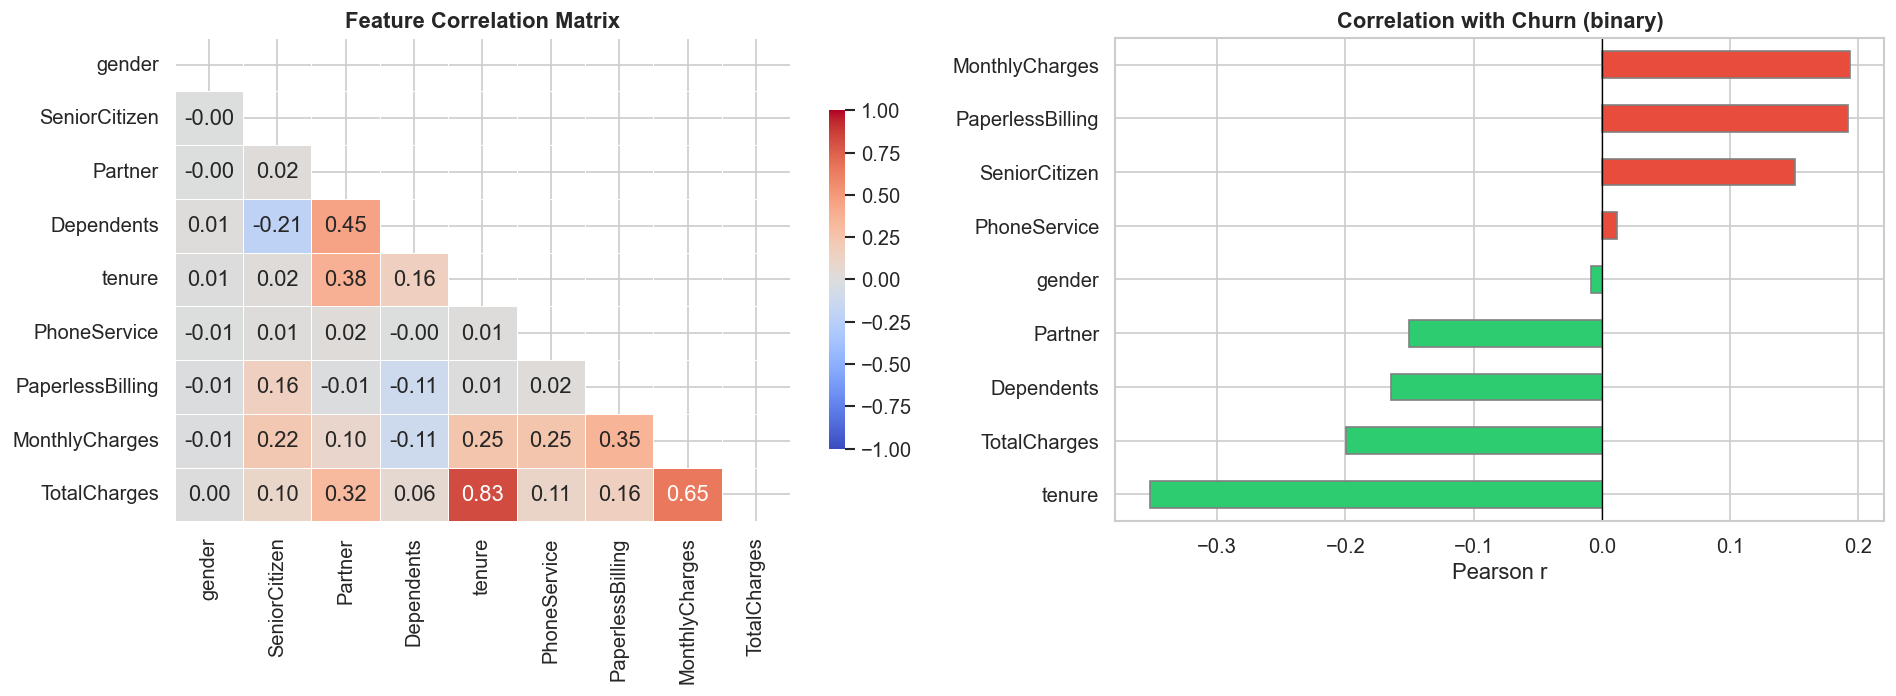

In [29]:
# build a numeric-only copy for correlation
df_corr = df.copy()
df_corr['TotalCharges']   = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')
df_corr['Churn_binary']   = (df_corr['Churn'] == 'Yes').astype(int)
df_corr['SeniorCitizen']  = df_corr['SeniorCitizen'].astype(int)  # already 0/1

# quick label-encode remaining binary cats
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    df_corr[col] = df_corr[col].map(binary_map)

numeric_df = df_corr.select_dtypes(include=[np.number]).drop(columns=['Churn_binary'])

corr_with_churn = df_corr[numeric_df.columns.tolist() + ['Churn_binary']].corr()['Churn_binary'].drop('Churn_binary').sort_values()

# full correlation matrix
corr_matrix = numeric_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# heatmap — full matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=axes[0],
            annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.7})
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')

# bar — correlation with Churn
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_with_churn]
corr_with_churn.plot(kind='barh', ax=axes[1], color=colors, edgecolor='grey')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with Churn (binary)', fontweight='bold')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

**Key observations from the heatmap:**
- `tenure` and `TotalCharges` are highly correlated (makes sense — longer tenure → more total spend).
- `MonthlyCharges` and `TotalCharges` are also correlated.
- `tenure` has the strongest *negative* correlation with churn — customers who stay longer are less likely to leave.
- `MonthlyCharges` has a positive correlation — higher bills → higher churn risk.

---
## 7. Data Cleaning <a id='7'></a>

Issues identified in Section 3:
| # | Issue | Fix |
|---|-------|-----|
| 1 | `TotalCharges` stored as `object` (whitespace for new customers) | Convert to `float`; fill with `0` for tenure=0 rows |
| 2 | `customerID` — not a feature | Drop |
| 3 | `SeniorCitizen` — int (0/1) but semantically binary | Leave as-is (int) |
| 4 | `Churn` — Yes/No string | Keep for now; encode in features notebook |
| 5 | Duplicate rows (if any) | Drop |

In [30]:
df_clean = df_raw.copy()

# ── Step 1 : Fix TotalCharges ─────────────────────────────────────────────────
# replace whitespace-only strings with NaN, then convert
df_clean['TotalCharges'] = df_clean['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# for customers with tenure == 0 the charge really is 0
df_clean.loc[df_clean['tenure'] == 0, 'TotalCharges'] = 0.0

# any remaining NaN (should be none after above, but just in case)
remaining_na = df_clean['TotalCharges'].isna().sum()
if remaining_na:
    df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

print(f'TotalCharges dtype  : {df_clean["TotalCharges"].dtype}')
print(f'Remaining NaN       : {df_clean["TotalCharges"].isna().sum()}')

TotalCharges dtype  : float64
Remaining NaN       : 0


In [31]:
# ── Step 2 : Drop customerID ──────────────────────────────────────────────────
df_clean.drop(columns=['customerID'], inplace=True)
print('customerID dropped ✔')

customerID dropped ✔


In [32]:
# ── Step 3 : Remove duplicate rows ───────────────────────────────────────────
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f'Rows before : {before:,}  |  Rows after : {len(df_clean):,}  |  Removed : {before - len(df_clean)}')

Rows before : 7,043  |  Rows after : 7,021  |  Removed : 22


In [33]:
# ── Step 4 : Sanity check ─────────────────────────────────────────────────────
print('=== Post-cleaning Summary ===')
print(f'Shape           : {df_clean.shape}')
print(f'Missing values  : {df_clean.isnull().sum().sum()}')
print(f'\nDtype overview :')
print(df_clean.dtypes.value_counts())
df_clean.describe().T

=== Post-cleaning Summary ===
Shape           : (7021, 20)
Missing values  : 0

Dtype overview :
object     16
int64       2
float64     2
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7021.0,0.162512,0.368947,0.00,0.00,0.00,0.0,1.00
tenure,7021.0,32.469449,24.534965,0.00,9.00,29.00,55.0,72.00
MonthlyCharges,7021.0,64.851894,30.069001,18.25,35.75,70.40,89.9,118.75
TotalCharges,7021.0,2286.765026,2266.855057,0.00,403.35,1400.55,3801.7,8684.80


### 7.1 Post-cleaning visualisation — TotalCharges distribution

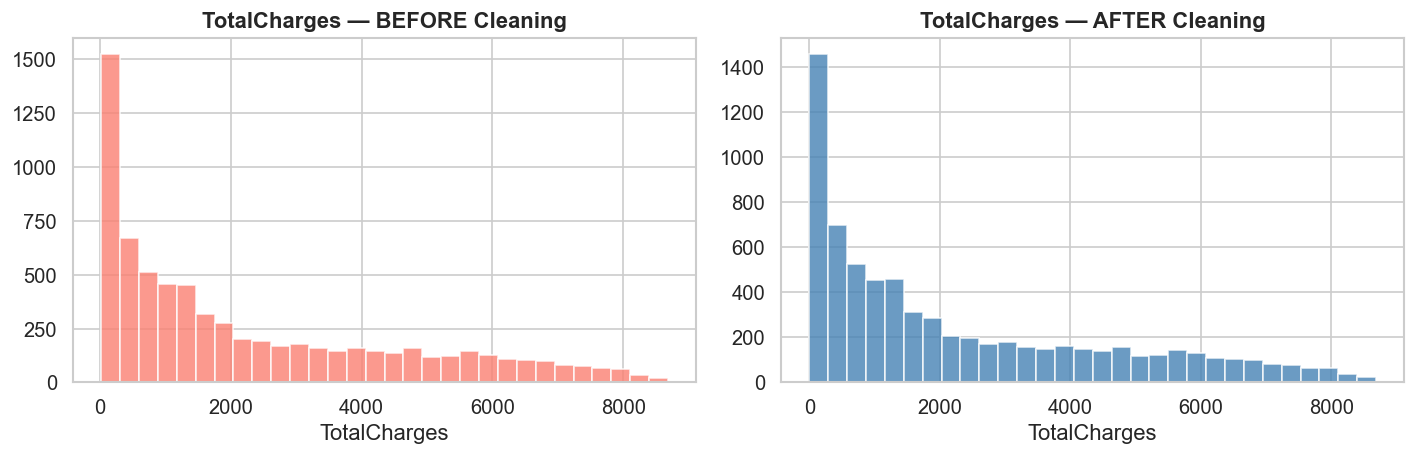

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pd.to_numeric(df_raw['TotalCharges'], errors='coerce').dropna(),
             bins=30, color='salmon', edgecolor='white', alpha=0.8)
axes[0].set_title('TotalCharges — BEFORE Cleaning', fontweight='bold')
axes[0].set_xlabel('TotalCharges')

axes[1].hist(df_clean['TotalCharges'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('TotalCharges — AFTER Cleaning', fontweight='bold')
axes[1].set_xlabel('TotalCharges')

plt.tight_layout()
plt.show()

### 7.2 Final cleaned column overview

In [35]:
summary = pd.DataFrame({
    'dtype'    : df_clean.dtypes,
    'nulls'    : df_clean.isnull().sum(),
    'unique'   : df_clean.nunique(),
    'sample'   : [df_clean[c].dropna().unique()[:3].tolist() for c in df_clean.columns]
})
summary

,dtype,nulls,unique,sample
gender,object,0,2,"[Female, Male]"
SeniorCitizen,int64,0,2,"[0, 1]"
Partner,object,0,2,"[Yes, No]"
Dependents,object,0,2,"[No, Yes]"
tenure,int64,0,73,"[1, 34, 2]"
PhoneService,object,0,2,"[No, Yes]"
MultipleLines,object,0,3,"[No phone service, No, Yes]"
InternetService,object,0,3,"[DSL, Fiber optic, No]"
OnlineSecurity,object,0,3,"[No, Yes, No internet service]"
OnlineBackup,object,0,3,"[Yes, No, No internet service]"


---
## 8. Save Cleaned Data <a id='8'></a>

In [36]:
os.makedirs('../data', exist_ok=True)

OUTPUT_PATH = '../data/telco_churn_clean.csv'
df_clean.to_csv(OUTPUT_PATH, index=False)

print(f'✅  Clean dataset saved → {OUTPUT_PATH}')
print(f'   Shape : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

✅  Clean dataset saved → ../data/telco_churn_clean.csv
   Shape : 7,021 rows × 20 columns


---
## ✅ Summary

| Step | Finding / Action |
|------|------------------|
| Schema | 21 columns → 20 after dropping `customerID` |
| Missing | Only `TotalCharges` had hidden whitespace → coerced to `float` |
| Duplicates | Checked and removed if any |
| Class imbalance | ~26 % churn (minority class) — will handle in modelling |
| Key insight | Short-tenure, high-monthly-charge, month-to-month contract customers churn most |
| Output | `data/telco_churn_clean.csv` — ready for `02_feature_engineering.ipynb` |